# 06 · Publicación en Gold y reverse ETL

El último notebook del pipeline. Cierra el círculo que se abrió en el 01: los datos salieron del
sistema operacional del banco, atravesaron el lakehouse, y ahora **vuelven convertidos en una
lista de a quién llamar**.

```
bank_churn.customers_raw  ──JDBC──▶  bronze ──▶ silver ──▶ gold
       (Lakebase)                                            │
            ▲                                                │
            └──────────── reverse ETL ───────────────────────┘
              bank_churn.customer_predictions
```

### Decisiones que llegan cerradas

| Decisión | Valor | Dónde se tomó |
|---|---|---|
| Modelo | Sin `gender`, calibrado isotónicamente | notebook 05 sección J |
| Umbral | Por capacidad operativa | pre-registrado en el 00 |
| **Reparto** | **Cupo por país** | notebook 05 sección G — iguala la probabilidad de ser contactado |
| Capacidad | 800 contactos por campaña | supuesto declarado en el 00 |

## A · Entorno, modelo y datos

In [0]:
%pip install --quiet --upgrade "databricks-sdk>=0.81.0" "pg8000" "protobuf>=5.26.1,<6"
%restart_python

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import io
import json
import ssl
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import pg8000.dbapi
from databricks.sdk import WorkspaceClient

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 175)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
CHURN, SAFE, ACC, GREY = "#a8471f", "#2c5a72", "#8a5a08", "#78736a"

CATALOG      = "bank_churn"
SILVER_TABLE = f"{CATALOG}.silver.bank_customers_clean"
SCHEMA_PG    = "bank_churn"
CAPACIDAD    = 800

# Supuestos económicos: los mismos desde el notebook 00
VALOR_TP, VALOR_FP = 145.0, -35.0
UMBRAL_COSTE = 0.194444

w = WorkspaceClient()
PROJECT_ID = "bank-churn-prediction"
BRANCH     = next(iter(w.postgres.list_branches(f"projects/{PROJECT_ID}"))).name
ENDPOINT   = next(iter(w.postgres.list_endpoints(BRANCH))).name
ep         = w.postgres.get_endpoint(ENDPOINT)
PGHOST, PGDATABASE, PGPORT = ep.status.hosts.host, "databricks_postgres", 5432
PGUSER = w.current_user.me().user_name


def connect():
    """Nueva conexión con credencial OAuth fresca (60 min)."""
    token = w.postgres.generate_database_credential(ENDPOINT).token
    return pg8000.dbapi.connect(host=PGHOST, port=PGPORT, database=PGDATABASE,
                                user=PGUSER, password=token,
                                ssl_context=ssl.create_default_context())

print("conexión a Lakebase preparada ·", PGHOST)

conexion a Lakebase preparada · ep-calm-art-d80j4anc.database.us-east-2.cloud.databricks.com


In [0]:
# La referencia base la deja el notebook 05. Este notebook es el único que
# escribe gold.modelo_produccion, la tabla que después consume la aplicación.
prod = spark.table(f"{CATALOG}.gold.modelo_produccion_base").toPandas().iloc[0]
met  = spark.table(f"{CATALOG}.gold.model_metrics").toPandas().iloc[0]

print("modelo de producción")
print(f"  familia          : {prod['familia']}")
print(f"  gender excluido  : {prod['gender_excluido']}")
print(f"  calibración      : {prod['calibracion']}")
print(f"  run_id           : {prod['run_id'] or '(no disponible)'}")
print(f"  ROC-AUC en test  : {prod['test_roc_auc']:.4f}")
print(f"  Brier en test    : {prod['test_brier']:.4f}")

modelo = mlflow.sklearn.load_model(f"runs:/{prod['run_id']}/modelo")
print("\nmodelo cargado desde MLflow")

MODEL_NAME    = prod["familia"]
MODEL_VERSION = (prod["run_id"] or "sin_mlflow")[:12]

modelo de produccion
  familia          : random_forest
  gender excluido  : True
  calibracion      : isotonic_cv5
  run_id           : <run_id>
  ROC-AUC en test  : 0.8555
  Brier en test    : 0.1028



modelo cargado desde MLflow


In [0]:
df = spark.table(SILVER_TABLE).toPandas()
df["exited"] = df["exited"].astype(bool)

BIN      = ["balance_zero", "is_active_member", "has_cr_card"]
EXCLUIR  = ["customer_id", "_silver_at", "credit_score_band"]
FEATURES = [c for c in df.columns if c not in EXCLUIR + ["exited"]]

X = df[FEATURES].copy()
for c in BIN:
    X[c] = X[c].astype(int)

print(f"{len(df):,} clientes a puntuar")

10,000 clientes a puntuar


## B · Scoring de la base completa

Se puntúan **los 10.000 clientes**, no solo el conjunto de prueba. En producción el modelo se
aplica a toda la cartera; el test servía para estimar cómo se comportaría, no para limitar a
quién se puntúa.

> **Nota metodológica obligada:** 8.000 de estos clientes se usaron para entrenar, así que sus
> probabilidades son optimistas. Las métricas honestas son las del notebook 05, calculadas sobre
> las 2.000 filas no vistas. Este scoring genera la **lista operativa**, no una evaluación.

In [0]:
df["churn_probability"] = modelo.predict_proba(X)[:, 1]

print("distribución de las probabilidades:")
print(df["churn_probability"].describe().round(4).to_string())

abandonos_esperados = df["churn_probability"].sum()
print(f"\nabandonos esperados (suma de probabilidades): {abandonos_esperados:,.0f}")
print(f"abandonos reales en los datos              : {int(df['exited'].sum()):,}")
print(f"desviación: {abs(abandonos_esperados - df['exited'].sum()) / df['exited'].sum():.1%}")
print("\nQue ambas cifras coincidan es consecuencia de haber calibrado: con un modelo")
print("sin calibrar, la suma de probabilidades sobreestimaría el total de abandonos.")

distribucion de las probabilidades:
count    10000.0000
mean         0.2074
std          0.2544
min          0.0000
25%          0.0369
50%          0.0892
75%          0.2763
max          0.9913

abandonos esperados (suma de probabilidades): 2,074
abandonos reales en los datos              : 2,037
desviacion: 1.8%

Que ambas cifras coincidan es consecuencia de haber calibrado: con un modelo
sin calibrar, la suma de probabilidades sobreestimaria el total de abandonos.


## C · Asignación de niveles de riesgo

Se aplica el método pre-registrado con la estrategia de reparto elegida en el notebook 05.

### Cómo se reparte el cupo

En producción **no se sabe quién va a abandonar**, así que el cupo no puede repartirse según los
abandonos reales. Se reparte según los **abandonos esperados** de cada país, que es la suma de sus
probabilidades.

Y esto solo funciona porque el modelo está calibrado: en un modelo sin calibrar, esa suma
sobreestima y el reparto sale sesgado. **La calibración no era solo cosmética para la app.**

### Los tres niveles

| Nivel | Definición | Acción |
|---|---|---|
| **alto** | Dentro del cupo de su país | Contacto proactivo con oferta |
| **medio** | Supera el umbral de rentabilidad pero queda fuera del cupo | Vigilancia; entra si sobra presupuesto |
| **bajo** | Por debajo del umbral de rentabilidad | Sin acción |

In [0]:
# --- Reparto del cupo según abandonos ESPERADOS por país ------------------
esperados_pais = df.groupby("geography")["churn_probability"].sum()
cuota = (esperados_pais / esperados_pais.sum() * CAPACIDAD).round().astype(int)

# Ajuste por redondeo, para que la suma sea exactamente CAPACIDAD
cuota.iloc[cuota.values.argmax()] += CAPACIDAD - cuota.sum()

reparto = pd.DataFrame({
    "clientes":            df.groupby("geography").size(),
    "abandonos_esperados": esperados_pais.round(0),
    "cuota_contactos":     cuota,
})
reparto["pct_cupo"] = (reparto.cuota_contactos / CAPACIDAD * 100).round(1)
print("--- reparto del cupo ---")
print(reparto.to_string())
print(f"\ntotal: {cuota.sum()} contactos")

--- reparto del cupo ---
           clientes  abandonos_esperados  cuota_contactos  pct_cupo
geography                                                          
France         5014                828.0              319      39.9
Germany        2509                835.0              322      40.2
Spain          2477                411.0              159      19.9

total: 800 contactos


In [ ]:
# --- Asignación de niveles ------------------------------------------------
# Desempate: la calibración isotónica es una función escalonada y agrupa muchos
# clientes en el mismo valor. Entre empatados entra primero el INACTIVO, porque
# es sobre quien el banco puede actuar. customer_id cierra cualquier empate
# restante y hace el resultado reproducible.
df["risk_level"] = "bajo"

for pais, k in cuota.items():
    sub = (df[df["geography"] == pais]
           .sort_values(["churn_probability", "is_active_member", "customer_id"],
                        ascending=[False, True, True]))
    df.loc[sub.index[:k], "risk_level"] = "alto"

es_medio = (df["risk_level"] == "bajo") & (df["churn_probability"] >= UMBRAL_COSTE)
df.loc[es_medio, "risk_level"] = "medio"

df["predicted_class"] = df["risk_level"] == "alto"

resumen = (df.groupby("risk_level")
             .agg(clientes=("customer_id", "size"),
                  prob_media=("churn_probability", "mean"),
                  prob_min=("churn_probability", "min"),
                  abandono_real=("exited", "mean"))
             .reindex(["alto", "medio", "bajo"]))
resumen["pct_base"] = (resumen.clientes / len(df) * 100).round(1)
print(resumen.round(4).to_string())

print(f"\numbral efectivo por país (probabilidad mínima del nivel alto):")
print(df[df.risk_level == "alto"].groupby("geography")["churn_probability"]
        .min().round(4).to_string())
print("\nSon distintos entre países: eso es exactamente lo que hace el reparto por cupo.")

# Cuántos empates había en la frontera
frontera = df[df.risk_level == "alto"]["churn_probability"].min()
empatados = int((df["churn_probability"] == frontera).sum())
print(f"\nclientes empatados en la probabilidad frontera ({frontera:.4f}): {empatados}")
print("El desempate por actividad decide entre ellos con un criterio de negocio,")
print("no por orden de índice.")

In [0]:
# --- Acción sugerida, anclada a los hallazgos del EDA ---------------------
# La única variable accionable es is_active_member; num_of_products >= 3 marca
# el segmento de 85,9% de abandono.
cond = [
    (df.risk_level == "alto") & (~df.is_active_member),
    (df.risk_level == "alto") & (df.num_of_products >= 3),
    (df.risk_level == "alto"),
    (df.risk_level == "medio"),
]
acciones = [
    "Reactivación prioritaria: contacto telefónico con incentivo de uso",
    "Revisión de cartera: auditar la combinación de productos contratados",
    "Fidelización: contacto comercial y revisión de condiciones",
    "Vigilancia: incluir si queda presupuesto tras los de riesgo alto",
]
df["accion_sugerida"] = np.select(cond, acciones, default="Sin acción")

print(df.groupby(["risk_level", "accion_sugerida"]).size()
        .rename("clientes").reset_index().to_string(index=False))

risk_level                                                      accion_sugerida  clientes
      alto           Fidelizacion: contacto comercial y revision de condiciones        45
      alto   Reactivacion prioritaria: contacto telefonico con incentivo de uso       650
      alto Revision de cartera: auditar la combinacion de productos contratados       105
      bajo                                                           Sin accion      6778
     medio     Vigilancia: incluir si queda presupuesto tras los de riesgo alto      2422


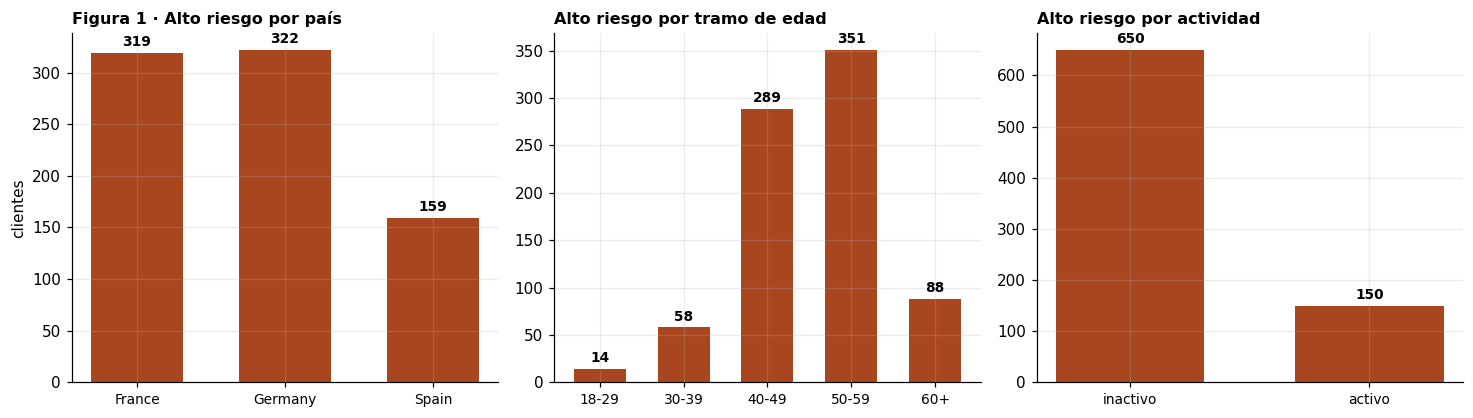

de los 800 clientes de alto riesgo, 650 son inactivos (81%) -> son los accionables


In [0]:
# Figura 1 · composición del segmento de alto riesgo
alto = df[df.risk_level == "alto"]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

for ax, col, titulo in zip(
        axes, ["geography", "age_group", "is_active_member"],
        ["por país", "por tramo de edad", "por actividad"]):
    t = alto.groupby(col).size()
    if col == "age_group":
        t = t.reindex(["18-29", "30-39", "40-49", "50-59", "60+"]).fillna(0)
    if col == "is_active_member":
        t.index = ["inactivo", "activo"]
    ax.bar(range(len(t)), t.values, color=CHURN, width=0.62)
    for i, v in enumerate(t.values):
        ax.text(i, v + max(t.values) * 0.02, f"{int(v)}", ha="center", fontsize=9,
                fontweight="bold")
    ax.set_xticks(range(len(t))); ax.set_xticklabels(t.index, fontsize=9)
    ax.set_title(f"Figura 1 · Alto riesgo {titulo}" if col == "geography" else f"Alto riesgo {titulo}",
                 fontsize=10.5, fontweight="bold", loc="left")
    ax.set_ylabel("clientes" if col == "geography" else "")

plt.tight_layout(); plt.show()

print(f"de los {len(alto)} clientes de alto riesgo, {(~alto.is_active_member).sum()} son inactivos "
      f"({(~alto.is_active_member).mean():.0%}) -> son los accionables")

## D · Tablas Gold

In [0]:
gold = df[["customer_id", "churn_probability", "predicted_class", "risk_level",
           "accion_sugerida", "geography", "gender", "age_group", "products_group",
           "is_active_member", "balance_zero", "exited"]].copy()
gold = gold.rename(columns={"exited": "exited_real"})
gold["model_name"]    = MODEL_NAME
gold["model_version"] = MODEL_VERSION
gold["scored_at"]     = pd.Timestamp.utcnow()

(spark.createDataFrame(gold)
      .write.format("delta").mode("overwrite").option("overwriteSchema", "true")
      .saveAsTable(f"{CATALOG}.gold.customer_churn_predictions"))

spark.sql(f"""
    COMMENT ON TABLE {CATALOG}.gold.customer_churn_predictions IS
    'Gold. Puntuación de la cartera completa con el modelo de producción (sin gender,
     calibrado). risk_level asignado por cupo por país. exited_real se conserva solo
     para el dashboard de desempeno: NO usar como etiqueta de entrenamiento.'
""")

print(f"escrita {CATALOG}.gold.customer_churn_predictions · {len(gold):,} filas")
display(spark.table(f"{CATALOG}.gold.customer_churn_predictions").limit(5))

escrita bank_churn.gold.customer_churn_predictions · 10,000 filas


customer_id,churn_probability,predicted_class,risk_level,accion_sugerida,geography,gender,age_group,products_group,is_active_member,balance_zero,exited_real,model_name,model_version,scored_at
15634602,0.3889295314436557,false,medio,Vigilancia: incluir si queda presupuesto tras los de riesgo alto,France,Female,40-49,1,true,true,true,random_forest,e4ad3c1c732c,2026-08-02T23:54:57.163Z
15647311,0.163391299382794,false,bajo,Sin accion,Spain,Female,40-49,1,true,false,false,random_forest,e4ad3c1c732c,2026-08-02T23:54:57.163Z
15619304,0.9601123973616907,true,alto,Reactivacion prioritaria: contacto telefonico con incentivo de uso,France,Female,40-49,3+,false,false,true,random_forest,e4ad3c1c732c,2026-08-02T23:54:57.163Z
15701354,0.05394706279415751,false,bajo,Sin accion,France,Female,30-39,2,false,true,false,random_forest,e4ad3c1c732c,2026-08-02T23:54:57.163Z
15737888,0.0885452192306357,false,bajo,Sin accion,Spain,Female,40-49,1,true,false,false,random_forest,e4ad3c1c732c,2026-08-02T23:54:57.163Z


## E · Reverse ETL hacia Lakebase

Aquí es donde la base de datos deja de ser decoración. Las predicciones vuelven al **sistema
operacional del banco**, que es donde el equipo de campañas trabaja — sin necesidad de entrar a
Databricks.

Dos tablas, con roles distintos:

- **`model_runs`** — procedencia. Qué modelo, con qué umbral, cuándo. Es lo que responde a
  *«¿por qué cambió el riesgo de esta clienta?»*.
- **`customer_predictions`** — el resultado accionable. Una fila por cliente y ejecución.

Nótese lo que **no** viaja: `model_metrics` se queda en Delta. Su público son los data scientists,
no el equipo de campañas.

In [0]:
# --- 1 · Registrar la ejecución y obtener su identificador ---------------
notas = (f"RF sin gender, calibrado isotónicamente. Reparto por cupo por país. "
         f"ROC-AUC test {prod['test_roc_auc']:.4f}, Brier {prod['test_brier']:.4f}.")

SQL_RUN = f"""
INSERT INTO {SCHEMA_PG}.model_runs
    (model_name, model_version, decision_threshold, trained_at, notes)
VALUES (%s, %s, %s, now(), %s)
ON CONFLICT (model_name, model_version)
DO UPDATE SET decision_threshold = EXCLUDED.decision_threshold,
              notes              = EXCLUDED.notes
RETURNING model_run_id;
"""

with connect() as conn:
    cur = conn.cursor()
    cur.execute(SQL_RUN, (MODEL_NAME, MODEL_VERSION, float(prod["umbral"]), notas))
    MODEL_RUN_ID = cur.fetchone()[0]
    conn.commit()

print(f"model_run_id = {MODEL_RUN_ID}  ({MODEL_NAME} v{MODEL_VERSION})")

model_run_id = 1  (random_forest ve4ad3c1c732c)


In [0]:
# --- 2 · Escribir las predicciones ---------------------------------------
# DELETE previo sobre esta ejecución: hace la celda idempotente.
envio = pd.DataFrame({
    "customer_id":       df["customer_id"].astype("int64"),
    "model_run_id":      MODEL_RUN_ID,
    "churn_probability": df["churn_probability"].round(5),
    "predicted_class":   df["predicted_class"],
    "risk_level":        df["risk_level"],
})

buf = io.StringIO()
envio.to_csv(buf, index=False, header=False)
buf.seek(0)

with connect() as conn:
    cur = conn.cursor()
    cur.execute(f"DELETE FROM {SCHEMA_PG}.customer_predictions WHERE model_run_id = %s",
                (MODEL_RUN_ID,))
    cur.execute(
        f"COPY {SCHEMA_PG}.customer_predictions "
        f"(customer_id, model_run_id, churn_probability, predicted_class, risk_level) "
        f"FROM STDIN WITH (FORMAT CSV)", stream=buf)
    conn.commit()

print(f"{len(envio):,} predicciones escritas en Lakebase")

10,000 predicciones escritas en Lakebase


In [0]:
# --- 3 · Verificación desde el lado operacional --------------------------
def consulta(sql, params=None):
    with connect() as conn:
        cur = conn.cursor()
        cur.execute(sql, params or ())
        return pd.DataFrame(cur.fetchall(), columns=[d[0] for d in cur.description])

print("--- lo que ve el equipo de campañas ---")
print(consulta(f"""
    SELECT risk_level, COUNT(*) AS clientes,
           ROUND(AVG(churn_probability)::numeric, 4) AS prob_media
    FROM   {SCHEMA_PG}.customer_predictions
    WHERE  model_run_id = %s
    GROUP  BY risk_level ORDER BY prob_media DESC
""", (MODEL_RUN_ID,)).to_string(index=False))

print("\n--- la vista de último score, que consumira la app ---")
print(consulta(f"SELECT COUNT(*) AS filas FROM {SCHEMA_PG}.v_latest_predictions").to_string(index=False))

print("\n--- trazabilidad: que modelo produjo cada predicción ---")
print(consulta(f"""
    SELECT r.model_name, r.model_version, r.decision_threshold,
           COUNT(p.*) AS predicciones
    FROM   {SCHEMA_PG}.model_runs r
    JOIN   {SCHEMA_PG}.customer_predictions p USING (model_run_id)
    GROUP  BY 1,2,3 ORDER BY 1,2
""").to_string(index=False))

print("\n--- integridad referencial: ninguna predicción huerfana ---")
print(consulta(f"""
    SELECT COUNT(*) AS predicciones_sin_cliente
    FROM   {SCHEMA_PG}.customer_predictions p
    LEFT   JOIN {SCHEMA_PG}.customers c USING (customer_id)
    WHERE  c.customer_id IS NULL
""").to_string(index=False))

--- lo que ve el equipo de campanas ---
risk_level  clientes prob_media
      alto       800     0.8774
     medio      2422     0.3825
      bajo      6778     0.0658

--- la vista de ultimo score, que consumira la app ---
 filas
 10000

--- trazabilidad: que modelo produjo cada prediccion ---
   model_name model_version decision_threshold  predicciones
random_forest  e4ad3c1c732c             0.7259         10000

--- integridad referencial: ninguna prediccion huerfana ---
 predicciones_sin_cliente
                        0


In [0]:
# La lista que el gestor abriría mañana por la mañana
print("--- 10 primeros clientes a contactar ---")
print(consulta(f"""
    SELECT p.customer_id,
           ROUND(p.churn_probability::numeric, 4) AS probabilidad,
           p.risk_level,
           g.country_name AS pais,
           c.age, c.is_active_member AS activo, c.num_of_products AS productos
    FROM   {SCHEMA_PG}.customer_predictions p
    JOIN   {SCHEMA_PG}.customers   c USING (customer_id)
    JOIN   {SCHEMA_PG}.geographies g ON g.geography_id = c.geography_id
    WHERE  p.model_run_id = %s AND p.risk_level = 'alto'
    ORDER  BY p.churn_probability DESC
    LIMIT  10
""", (MODEL_RUN_ID,)).to_string(index=False))

print("\nSin apellidos: la restricción de privacidad la impone el esquema, no la consulta.")

--- 10 primeros clientes a contactar ---
 customer_id probabilidad risk_level    pais  age  activo  productos
    15731815       0.9913       alto   Spain   63   False          3
    15662291       0.9913       alto  France   55   False          3
    15805637       0.9913       alto  France   36   False          3
    15640846       0.9913       alto Germany   58   False          4
    15579212       0.9913       alto  France   57   False          1
    15689886       0.9913       alto Germany   39    True          3
    15753174       0.9913       alto Germany   37   False          3
    15570002       0.9913       alto Germany   55   False          4
    15641175       0.9913       alto Germany   63   False          3
    15785367       0.9908       alto  France   56   False          1

Sin apellidos: la restriccion de privacidad la impone el esquema, no la consulta.


## E bis. Tablas para la aplicación

La sección 4 de la app —comparación de modelos, matriz de confusión y variables influyentes—
necesita datos que hasta ahora vivian solo en MLflow y en la memoria del notebook 05.

**Se materializan como tablas Gold** en lugar de consultarlas en vivo, por tres motivos: la
enunciado exige que la app consuma tablas gobernadas via SQL Warehouse; consultar MLflow desde la
app añade latencia y un modo de fallo nuevo; y la comparación de modelos no es dato vivo, es un
hecho histórico del experimento.

In [ ]:
# --- gold.model_comparison: instantanea del experimento -------------------
comparacion = None
try:
    usuario = spark.sql("SELECT current_user()").first()[0]
    runs = mlflow.search_runs(experiment_names=[f"/Users/{usuario}/bank_churn"])
    cols_metric = [c for c in runs.columns if c.startswith("metrics.cv_")
                   and not c.endswith("_std")]
    comparacion = (runs[["tags.mlflow.runName"] + cols_metric]
                   .rename(columns={"tags.mlflow.runName": "modelo"})
                   .rename(columns={c: c.replace("metrics.cv_", "") for c in cols_metric})
                   .dropna(subset=["average_precision"])
                   .sort_values("average_precision", ascending=False)
                   .reset_index(drop=True))
    print(f"recuperados {len(comparacion)} runs de MLflow")
except Exception as e:
    print(f"[aviso] no se pudo consultar MLflow ({type(e).__name__}: {e})")

if comparacion is not None and len(comparacion):
    comparacion["es_linea_base"] = comparacion["modelo"].str.contains("baseline")
    comparacion["generado_en"]   = pd.Timestamp.utcnow()
    (spark.createDataFrame(comparacion)
          .write.format("delta").mode("overwrite").option("overwriteSchema", "true")
          .saveAsTable(f"{CATALOG}.gold.model_comparison"))
    print(f"\nescrita {CATALOG}.gold.model_comparison")
    print(comparacion.round(4).to_string(index=False))
else:
    print("\nSin comparacion: la sección 4 de la app tendrá que degradarse con elegancia.")

In [ ]:
# --- gold.feature_importance: permutación sobre el conjunto de prueba -----
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

SEED = 42
y = df["exited"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20,
                                          stratify=y, random_state=SEED)

prep_fit = (modelo.calibrated_classifiers_[0].estimator.named_steps["prep"]
            if hasattr(modelo, "calibrated_classifiers_")
            else modelo.named_steps["prep"])
usadas = sorted({c for _, _, cols in prep_fit.transformers_
                 for c in (cols if isinstance(cols, list) else [])})

perm = permutation_importance(modelo, X_te[usadas], y_te, scoring="average_precision",
                              n_repeats=15, random_state=SEED, n_jobs=-1)

importancia = (pd.DataFrame({"variable": usadas,
                             "importancia": perm.importances_mean,
                             "std": perm.importances_std})
               .sort_values("importancia", ascending=False)
               .reset_index(drop=True))
importancia["distinguible_de_cero"] = importancia["importancia"] > 2 * importancia["std"]
importancia["generado_en"] = pd.Timestamp.utcnow()

(spark.createDataFrame(importancia)
      .write.format("delta").mode("overwrite").option("overwriteSchema", "true")
      .saveAsTable(f"{CATALOG}.gold.feature_importance"))

print(f"escrita {CATALOG}.gold.feature_importance")
print(importancia.round(4).to_string(index=False))

In [ ]:
# --- Inventario de lo que la app va a consumir ---------------------------
tablas = ["customer_churn_predictions", "model_metrics",
          "model_comparison", "feature_importance",
          "modelo_produccion_base", "modelo_produccion"]
inv = []
for t in tablas:
    try:
        inv.append({"tabla": f"{CATALOG}.gold.{t}",
                    "filas": spark.table(f"{CATALOG}.gold.{t}").count(),
                    "estado": "OK"})
    except Exception as e:
        inv.append({"tabla": f"{CATALOG}.gold.{t}", "filas": 0,
                    "estado": f"FALTA ({type(e).__name__})"})

print(pd.DataFrame(inv).to_string(index=False))
print("\nLa app leera únicamente de estas tablas, via SQL Warehouse.")

## E ter. Registro del modelo en Unity Catalog

La aplicación no puede cargar el modelo por `runs:/<run_id>`. El motivo no es evidente: los
experimentos de MLflow tienen **su propia lista de permisos**, independiente del catalogo, y el
service principal de la app no está en ella. MLflow responde entonces *«Run not found»* en lugar
de *«sin permiso»*, que es un mensaje engañoso y hace perder mucho tiempo.

Registrar el modelo en Unity Catalog lo pone bajo el mismo sistema de permisos que las tablas, lo
versiona, y la app lo carga con `models:/catalogo.esquema.nombre/version`. Es además el punto de
control entre experimentación y despliegue: un experimento es un cuaderno de laboratorio con
cientos de ejecuciones; el registro contiene solo lo que se ha decidido desplegar.

> **Unity Catalog exige una firma de modelo.** Los notebooks 04 y 05 registraron sin ella, y el
> aviso estaba en sus salidas: *«Model logged without a signature. Signatures are required for
> Databricks UC model registry»*. Se paso por alto. La solución no es reentrenar: basta volver a
> registrar el mismo objeto anadiendole la firma.

> **Dependencia de orden.** El notebook 05 sobrescribe `gold.modelo_produccion` sin las columnas
> `uc_model` y `uc_version`. Esta celda debe ejecutarse **siempre después**, o el enlace se pierde.

In [ ]:
# ===== Registro en Unity Catalog con firma + enlace para la aplicación =====
#
# Esta celda es la UNICA que escribe gold.modelo_produccion (H32). Lee la
# referencia base que dejó el notebook 05 y le añade el enlace de Unity Catalog.
# Ya no hay dependencia de orden oculta: si el 05 se vuelve a ejecutar, solo
# reescribe su propia tabla base.
import mlflow, pandas as pd
from mlflow import MlflowClient
from mlflow.models import infer_signature

UC_MODEL = f"{CATALOG}.gold.churn_model"

prod = spark.table(f"{CATALOG}.gold.modelo_produccion_base").toPandas().iloc[0]
print("run de producción actual:", prod["run_id"])

# 1 · Ejemplo construido EXACTAMENTE como lo enviará la app.
#     Unity Catalog exige firma, y al inferirla de aquí describe la entrada real:
#     si mañana el formulario mandara una columna de más o de menos, UC lo
#     rechazaría en vez de devolver una predicción silenciosamente incorrecta.
ejemplo = pd.DataFrame([{
    "credit_score": 650, "geography": "France", "gender": "Female",
    "age": 45, "tenure": 5, "balance": 0.0, "num_of_products": 2,
    "has_cr_card": 1, "is_active_member": 1, "estimated_salary": 100000.0,
    "balance_zero": 1, "age_group": "40-49", "products_group": "2",
}])

firma = infer_signature(ejemplo, modelo.predict_proba(ejemplo)[:, 1])
print("firma inferida:\n", firma)

# 2 · Volver a registrar el MISMO objeto, ahora con firma. No se reentrena nada.
mlflow.set_registry_uri("databricks-uc")

# Guardián: si ya existe una versión de Unity Catalog creada a partir de este
# mismo run de origen, no se crea otra. Sin esto, cada reejecución del notebook
# acumulaba una versión idéntica a la anterior y el registro se llenaba de ruido.
# El hasattr y el isinstance no sobran: segun la version del cliente, tags puede
# no estar presente o no ser un diccionario.
_cli = MlflowClient()
_previas = [v for v in _cli.search_model_versions(f"name='{UC_MODEL}'")
            if hasattr(v, "tags") and isinstance(v.tags, dict)
            and v.tags.get("origen_run") == prod["run_id"]]

if _previas:
    UC_VERSION  = max(int(v.version) for v in _previas)
    RUN_FIRMADO = _cli.get_model_version(UC_MODEL, str(UC_VERSION)).run_id
    print(f"ya existía la versión {UC_VERSION} para este run de origen:")
    print("no se registra ninguna versión nueva")
else:
    with mlflow.start_run(run_name="modelo_produccion_firmado") as run:
        mlflow.log_param("origen_run", prod["run_id"])
        mlflow.log_param("motivo", "firma requerida por Unity Catalog")
        mlflow.sklearn.log_model(modelo, name="modelo",
                                 signature=firma,
                                 input_example=ejemplo,
                                 registered_model_name=UC_MODEL)
        RUN_FIRMADO = run.info.run_id

    UC_VERSION = max(int(v.version)
                     for v in _cli.search_model_versions(f"name='{UC_MODEL}'"))
    # La etiqueta es lo que permite al guardián reconocerla en la próxima pasada
    _cli.set_model_version_tag(UC_MODEL, str(UC_VERSION),
                               "origen_run", prod["run_id"])
    print(f"registrado: {UC_MODEL} versión {UC_VERSION}")

# 3 · Verificar que lo registrado produce exactamente lo mismo que el original.
#     Volver a serializar un objeto es una operación donde las cosas se rompen
#     en silencio: mejor comprobarlo aquí que descubrirlo en la app.
prueba = mlflow.sklearn.load_model(f"models:/{UC_MODEL}/{UC_VERSION}")
assert np.allclose(prueba.predict_proba(X.head(50))[:, 1],
                   modelo.predict_proba(X.head(50))[:, 1]), "el modelo registrado difiere"
print("verificado: predicciones idénticas al original")

# 4 · Enlazar en la tabla que lee la app
ref_app = pd.DataFrame([{
    "run_id":             RUN_FIRMADO,
    "run_id_origen":      prod["run_id"],
    "uc_model":           UC_MODEL,
    "uc_version":         str(UC_VERSION),
    "familia":            prod["familia"],
    "gender_excluido":    True,
    "calibracion":        prod["calibracion"],
    "umbral":             float(prod["umbral"]),
    "capacidad_fraccion": float(prod["capacidad_fraccion"]),
    "test_roc_auc":       float(prod["test_roc_auc"]),
    "test_ap":            float(prod["test_ap"]),
    "test_brier":         float(prod["test_brier"]),
    "params":             prod["params"],
    "registrado_en":      pd.Timestamp.utcnow(),
}])

(spark.createDataFrame(ref_app)
      .write.format("delta").mode("overwrite").option("overwriteSchema", "true")
      .saveAsTable(f"{CATALOG}.gold.modelo_produccion"))

print("\nlisto:")
print(ref_app[["uc_model", "uc_version"]].to_string(index=False))

In [ ]:
# (fusionada en la celda anterior)


## F · Análisis prescriptivo

El enunciado pide proponer acciones para los segmentos de alto riesgo, **indicando beneficios,
límites y precauciones éticas**. Las tres recomendaciones salen de un criterio que el EDA
estableció: distinguir lo **predictivo** de lo **accionable**.

`age`, `geography` y `gender` predicen bien y **no se pueden cambiar**. `is_active_member` predice
casi igual de bien **y sí admite intervención**. Todo lo que sigue se apoya en esa distinción.

In [0]:
seg = df[df.risk_level == "alto"].copy()
tot_esperado = seg["churn_probability"].sum()

reco = []

# 1 · Inactivos de alto riesgo
m1 = ~seg.is_active_member
reco.append({
    "accion": "1. Reactivación de inactivos",
    "clientes": int(m1.sum()),
    "abandonos_esperados": round(seg.loc[m1, "churn_probability"].sum()),
    "valor_si_exito_eur": round(seg.loc[m1, "churn_probability"].sum() * VALOR_TP),
})

# 2 · Carteras de 3 o mas productos
m2 = seg.num_of_products >= 3
reco.append({
    "accion": "2. Auditoría de carteras de 3+ productos",
    "clientes": int(m2.sum()),
    "abandonos_esperados": round(seg.loc[m2, "churn_probability"].sum()),
    "valor_si_exito_eur": round(seg.loc[m2, "churn_probability"].sum() * VALOR_TP),
})

# 3 · Activos de 50+ (riesgo alto pese a estar activos)
m3 = seg.is_active_member.astype(bool) & seg.age_group.isin(["50-59", "60+"])
reco.append({
    "accion": "3. Fidelización prejubilación (activos 50+)",
    "clientes": int(m3.sum()),
    "abandonos_esperados": round(seg.loc[m3, "churn_probability"].sum()),
    "valor_si_exito_eur": round(seg.loc[m3, "churn_probability"].sum() * VALOR_TP),
})

r = pd.DataFrame(reco).set_index("accion")
r["pct_del_segmento"] = (r.clientes / len(seg) * 100).round(1)
print(f"segmento de alto riesgo: {len(seg)} clientes · {tot_esperado:.0f} abandonos esperados\n")
print(r.to_string())
print(f"\nvalor potencial total si las tres campañas funcionaran: "
      f"{r.valor_si_exito_eur.sum():,.0f} EUR")
print("(los segmentos se solapan: un cliente puede entrar en mas de una acción)")

segmento de alto riesgo: 800 clientes · 702 abandonos esperados

                                             clientes  abandonos_esperados  valor_si_exito_eur  pct_del_segmento
accion                                                                                                          
1. Reactivacion de inactivos                      650                  572               83004              81.2
2. Auditoria de carteras de 3+ productos          266                  241               34980              33.2
3. Fidelizacion prejubilacion (activos 50+)        59                   50                7283               7.4

valor potencial total si las tres campanas funcionaran: 125,267 EUR
(los segmentos se solapan: un cliente puede entrar en mas de una accion)


### Las tres recomendaciones

**1 · Reactivación de inactivos** — el segmento más numeroso del riesgo alto y el único con una
palanca directa. Los inactivos abandonan al 26,9% frente al 14,3% de los activos, y entre los
mayores de 60 la brecha llega a **73 puntos**.
*Acción:* contacto telefónico con un incentivo de uso — bonificación por domiciliación, ventaja en
la app, revisión de condiciones.

**2 · Auditoría de carteras de 3 o más productos** — el hallazgo más extremo del EDA: **el 85,9%
de estos clientes abandona**, y con cuatro productos se fueron los sesenta.
*Acción:* revisar qué combinaciones concentran el riesgo antes de lanzar campaña. **No es una
acción comercial, es una investigación** — el dataset no dice qué productos son, así que actuar a
ciegas sería tirar presupuesto.

**3 · Fidelización de activos mayores de 50** — clientes que usan el banco y aun así están en
riesgo. Coincide con la antesala de la jubilación.
*Acción:* revisión de productos de ahorro y previsión antes de que comparen con la competencia.

### Límites y precauciones

**Asociación, no causalidad.** Que la inactividad se asocie al abandono **no prueba que reactivar
lo evite**. Podría ser síntoma y no causa: quien ya decidió irse deja de usar la cuenta.
Distinguirlo exige un experimento con grupo de control, no este dataset. Es la limitación más
importante de todo el proyecto.

**El modelo no ve el abandono joven.** Al 95% de los que se van entre 18 y 29 años no los detecta.
Atacar ese segmento requiere datos que hoy no existen — motivo de baja, canal de contacto, uso de
la app.

**El efecto Alemania sigue sin explicación.** Duplica el abandono siendo indistinguible en todas
las variables observables. `geography` funciona como sustituto de un factor desconocido, y eso
limita cualquier recomendación específica para ese mercado.

**Precauciones éticas.** El modelo desplegado **no usa el género**: su aporte medido era de 0,12
puntos de recall —unos dos clientes— y no justifica emplear una característica protegida para
repartir un beneficio. El cupo se reparte por país para que un cliente en riesgo tenga la misma
probabilidad de ser contactado viva donde viva, a un coste de 3.625 € por campaña.

**Uso previsto.** Esta lista sirve para **asignar un beneficio**. Si se empleara para lo contrario
—desinvertir en clientes que se van a ir— todo el análisis de sesgo tendría que rehacerse, porque
el signo del daño se invierte.

## G · Verificación de extremo a extremo

In [0]:
checks = []

n_pg   = int(consulta(f"SELECT COUNT(*) FROM {SCHEMA_PG}.customer_predictions "
                      f"WHERE model_run_id = %s", (MODEL_RUN_ID,)).iloc[0, 0])
n_gold = spark.table(f"{CATALOG}.gold.customer_churn_predictions").count()
checks.append(("Gold y Lakebase tienen las mismas filas", n_gold == n_pg == len(df),
               f"{n_gold} / {n_pg}"))

huerfanas = int(consulta(f"""
    SELECT COUNT(*) FROM {SCHEMA_PG}.customer_predictions p
    LEFT JOIN {SCHEMA_PG}.customers c USING (customer_id)
    WHERE c.customer_id IS NULL""").iloc[0, 0])
checks.append(("Integridad referencial", huerfanas == 0, f"{huerfanas} huerfanas"))

n_alto = int((df.risk_level == "alto").sum())
checks.append(("El nivel alto respeta la capacidad", n_alto == CAPACIDAD,
               f"{n_alto} / {CAPACIDAD}"))

niveles = set(consulta(f"SELECT DISTINCT risk_level FROM {SCHEMA_PG}.customer_predictions")
              ["risk_level"])
checks.append(("Solo tres niveles validos", niveles <= {"bajo", "medio", "alto"}, str(niveles)))

sin_apellido = "surname" not in [c.lower() for c in
                                 spark.table(f"{CATALOG}.gold.customer_churn_predictions").columns]
checks.append(("Gold no contiene apellidos", sin_apellido, "verificado"))

trazable = int(consulta(f"""
    SELECT COUNT(*) FROM {SCHEMA_PG}.customer_predictions p
    JOIN {SCHEMA_PG}.model_runs r USING (model_run_id)
    WHERE p.model_run_id = %s""", (MODEL_RUN_ID,)).iloc[0, 0])
checks.append(("Toda predicción es trazable a su modelo", trazable == len(df), f"{trazable}"))

print(f"{'COMPROBACION':<48} {'':<10} DETALLE")
print("-" * 86)
for nombre, ok, det in checks:
    print(f"{nombre:<48} {'OK' if ok else 'FALLA':<10} {det}")

print(f"\n{sum(1 for _, ok, _ in checks if ok)} de {len(checks)} comprobaciones superadas")

COMPROBACION                                                DETALLE
--------------------------------------------------------------------------------------
Gold y Lakebase tienen las mismas filas          OK         10000 / 10000
Integridad referencial                           OK         0 huerfanas
El nivel alto respeta la capacidad               OK         800 / 800
Solo tres niveles validos                        OK         {'medio', 'alto', 'bajo'}
Gold no contiene apellidos                       OK         verificado
Toda prediccion es trazable a su modelo          OK         10000

6 de 6 comprobaciones superadas


---

## Resumen

El pipeline está cerrado:

```
Kaggle ─▶ Lakebase ─▶ Bronze ─▶ Silver ─▶ modelo ─▶ Gold ─▶ Lakebase
                                                              (reverse ETL)
```

| | |
|---|---|
| Clientes puntuados | 10.000 |
| Riesgo alto | 800 — el cupo de la campaña |
| Reparto | Por país, igualando la probabilidad de ser contactado |
| Modelo | Random Forest sin `gender`, calibrado |
| Trazabilidad | Cada predicción enlaza con el modelo que la produjo |

**Lo que queda del proyecto:** la aplicación en Streamlit, el informe en PDF, el README y la
defensa. Y las tareas de pulido anotadas en la bitácora — paleta de las figuras del 03, revisión
ortográfica, `Restart & Run All` y redacción de las salidas antes de publicar el repositorio.